#**Smart Digital Twin System for Personal Productivity Prediction**

Notebook ini menggunakan model Multi-Output LSTM untuk menganalisis aktivitas pengguna dan menghasilkan dua jenis prediksi sekaligus, yaitu:

 - Prediksi skor produktivitas
 - Prediksi kategori kondisi pengguna:
   1. At Risk
   2. Steady
   3. Thriving

Model dibuat menggunakan pendekatan Deep Learning berbasis data time series untuk memahami pola aktivitas harian pengguna selama beberapa hari terakhir.

**Roadmap Proyek**

 - Eksplorasi dan Pemahaman Data Dasar (EDA)
 - Analisis Karakteristik Time Series
 - Feature Engineering dan Pelabelan Data
 - Preprocessing Data (Anti Data Leakage)
 - Perancangan Model Multi-Output LSTM
 - Pelatihan Model dan Monitoring
 - Evaluasi Kinerja Model
 - Simulasi Prediksi

##**1. Library**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import tensorflow as tf
import datetime

from tensorflow.keras import layers
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


##**2. Eksplorasi & Pemahaman Data Dasar (EDA)**

Tahap awal untuk memahami struktur dataset, tipe data, serta kondisi data sebelum diproses lebih lanjut.

###**2.1 Memasukkan dan Memeriksa Data Awal**

**Pada tahap ini dilakukan:**
- membaca dataset,
- melihat ukuran data,
- mengecek tipe data,
- menampilkan beberapa data awal.

In [2]:
#baca dataset
df = pd.read_csv('final_dataset_model_ready.csv')
print("Dimensi Dataset:", df.shape)
print("\nInformasi Kolom & Tipe Data:")
df.info()

Dimensi Dataset: (73100, 18)

Informasi Kolom & Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              73100 non-null  int64  
 1   date                 73100 non-null  object 
 2   is_weekend           73100 non-null  int64  
 3   sleep_duration       73100 non-null  float64
 4   study_work_duration  73100 non-null  float64
 5   break_duration       73100 non-null  float64
 6   exercise_duration    73100 non-null  float64
 7   downtime_duration    73100 non-null  float64
 8   stress_level         73100 non-null  int64  
 9   mood_score           73100 non-null  int64  
 10  focus_score          73100 non-null  int64  
 11  task_planned         73100 non-null  int64  
 12  task_completed       73100 non-null  int64  
 13  completion_ratio     73100 non-null  float64
 14  fatigue_index        73100 

In [3]:
print("\n5 Data Teratas:")
df.head()


5 Data Teratas:


,user_id,date,is_weekend,sleep_duration,study_work_duration,break_duration,exercise_duration,downtime_duration,stress_level,mood_score,focus_score,task_planned,task_completed,completion_ratio,fatigue_index,cumulative_fatigue,productivity_score,productivity_label
0,1,2024-01-01,0,7.26,6.62,0.870000,30.0,8.75,4,3,7,8,6,0.750,54.83,54.83,59.25,1
1,1,2024-01-02,0,7.58,8.47,0.000000,54.0,8.15,6,5,2,10,0,0.000,66.41,55.99,40.42,0
2,1,2024-01-03,0,8.16,6.98,2.796667,26.0,5.63,2,6,7,8,8,1.000,37.10,54.10,52.32,0
3,1,2024-01-04,0,7.57,8.36,0.100000,57.0,7.02,4,4,6,10,0,0.000,53.20,54.01,43.31,0
4,1,2024-01-05,0,7.89,6.89,3.050000,48.0,5.37,4,4,6,8,7,0.875,46.25,53.23,59.32,1


###**2.2 Statistik Deskriptif**

Menampilkan ringkasan statistik dari setiap fitur numerik seperti:
- rata-rata,
- nilai minimum,
- nilai maksimum,
- dan standar deviasi.

In [4]:
print("Ringkasan Statistik Deskriptif:")
df.describe()

Ringkasan Statistik Deskriptif:


,user_id,is_weekend,sleep_duration,study_work_duration,break_duration,exercise_duration,downtime_duration,stress_level,mood_score,focus_score,task_planned,task_completed,completion_ratio,fatigue_index,cumulative_fatigue,productivity_score,productivity_label
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,50.500000,0.258933,7.217740,6.521535,2.951895,27.720930,6.520567,4.220752,6.164938,5.686990,7.982722,5.373174,0.740462,49.793233,49.854060,62.599693,1.021395
std,28.866267,0.438052,0.924694,3.214439,2.380459,19.378523,1.713863,1.336361,1.590012,1.742516,3.531937,2.688178,0.288573,11.531324,4.057195,9.876914,0.697396
min,1.000000,0.000000,4.715000,0.000000,0.000000,0.000000,1.850000,1.000000,2.000000,2.000000,3.000000,0.000000,0.000000,12.640000,35.150000,25.460000,0.000000
25%,25.750000,0.000000,6.590000,2.980000,0.440000,12.000000,5.360000,3.000000,5.000000,5.000000,4.000000,3.000000,0.538000,41.570000,47.090000,55.587500,1.000000
50%,50.500000,0.000000,7.210000,7.140000,2.690000,26.000000,6.560000,4.000000,6.000000,6.000000,9.000000,5.000000,0.833000,50.320000,49.140000,63.090000,1.000000
75%,75.250000,1.000000,7.840000,8.750000,6.000000,41.000000,7.700000,5.000000,7.000000,7.000000,10.000000,7.000000,1.000000,57.950000,51.720000,70.100000,2.000000
max,100.000000,1.000000,9.715000,17.405000,6.000000,84.500000,11.210000,8.000000,10.000000,10.000000,15.000000,15.000000,1.000000,89.750000,76.820000,89.520000,2.000000


##**3. Analisis Karakteristik Time Series**
untuk memahami pola data berdasarkan urutan waktu.

##**3.1 Definisi Fitur dan Target**

Menentukan:
- fitur input yang digunakan model,
- target prediksi produktivitas.

In [5]:
raw_features = [
    'is_weekend',
    'sleep_duration',
    'study_work_duration',
    'break_duration',
    'exercise_duration',
    'downtime_duration',
    'stress_level',
    'mood_score',
    'focus_score',
    'task_planned',
    'task_completed',
    'completion_ratio',
    'fatigue_index',
    'cumulative_fatigue',
]

target_col = 'productivity_score'
target_clf = 'productivity_label'

print("Fitur input mentah:", raw_features)
print("Target Regresi:", target_col)
print("Target klasifikasi:", target_clf)

Fitur input mentah: ['is_weekend', 'sleep_duration', 'study_work_duration', 'break_duration', 'exercise_duration', 'downtime_duration', 'stress_level', 'mood_score', 'focus_score', 'task_planned', 'task_completed', 'completion_ratio', 'fatigue_index', 'cumulative_fatigue']
Target Regresi: productivity_score
Target klasifikasi: productivity_label


###**3.2 Visualisasi Korelasi Fitur**
untuk melihat hubungan antar fitur dan pengaruhnya terhadap produktivitas pengguna.

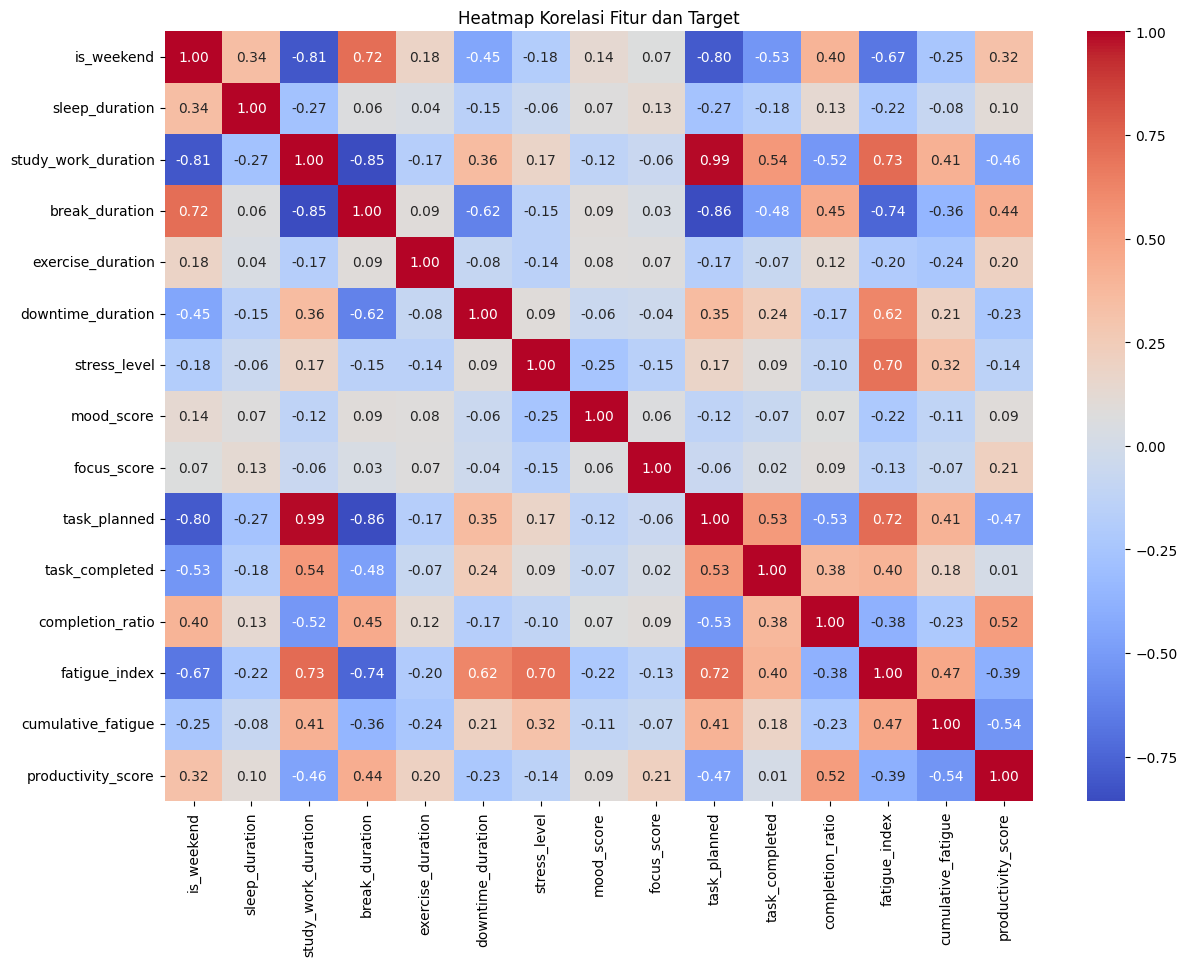

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[raw_features + [target_col]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur dan Target")
plt.show()

###**3.3 Time Series Decomposition**

Analisis dekomposisi dilakukan untuk memisahkan:
- tren,
- pola musiman,
- dan residual/noise

dari data produktivitas pengguna.

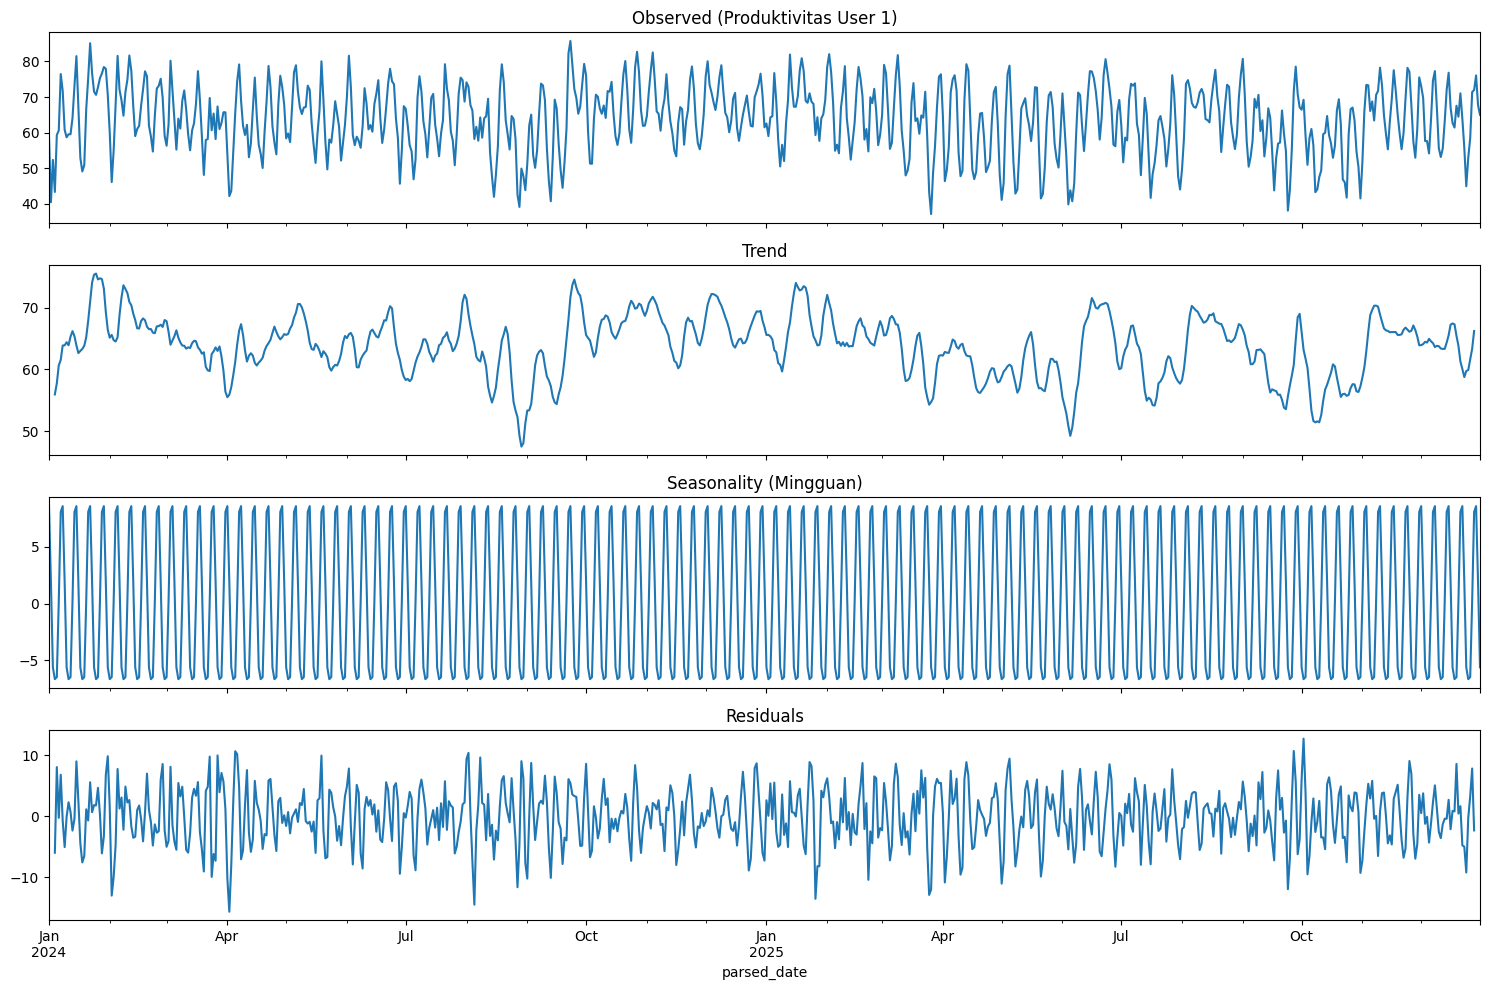

In [7]:
#dekomposisi deret waktu untuk user 1 secara berurutan waktu
df_u1 = df[df['user_id'] == 1].copy()
df_u1['parsed_date'] = pd.to_datetime(df_u1['date'], format='%Y-%m-%d')
df_u1 = df_u1.sort_values(by='parsed_date').set_index('parsed_date')

decomposition = seasonal_decompose(df_u1['productivity_score'], model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomposition.observed.plot(ax=ax1, title='Observed (Produktivitas User 1)')
decomposition.trend.plot(ax=ax2, title='Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonality (Mingguan)')
decomposition.resid.plot(ax=ax4, title='Residuals')
plt.tight_layout()
plt.show()

##**3.4 Analisis Window Size Menggunakan ACF & PACF**

untuk menentukan panjang window sequence yang optimal pada model LSTM.

disini digunakan window size 7 hari karena sesuai dengan pola aktivitas mingguan pengguna.

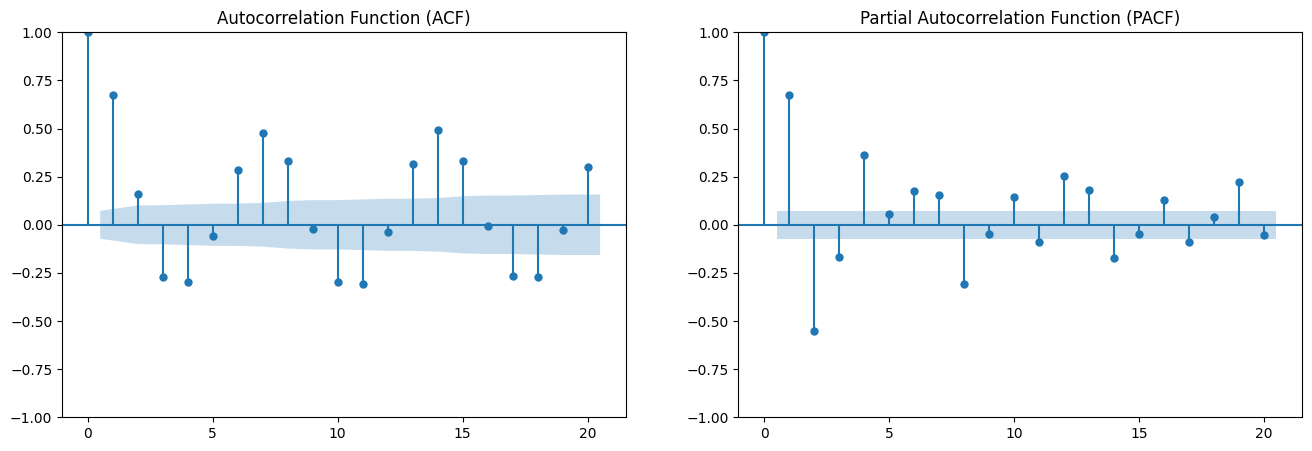

Hasil Analisis Data ACF/PACF
* Lag Awal: Nilai autokorelasi lag 1 (0.676) berada DI LUAR batas signifikansi (±0.072). Ada tren atau dependensi jangka pendek.
* Siklus Mingguan: Terdeteksi korelasi signifikan pada lag 7 (0.474).
  Kesimpulan: Hipotesis pola perilaku mingguan (hari kerja vs akhir pekan) TERBUKTI secara statistik pada data ini.
  Rekomendasi: Sangat disarankan menggunakan window size = 7 hari.


In [8]:
# fig, ax = plt.subplots(1, 2, figsize=(16, 5))
# plot_acf(df_u1['productivity_score'], lags=20, ax=ax[0], title='Autocorrelation Function (ACF)')
# plot_pacf(df_u1['productivity_score'], lags=20, ax=ax[1], title='Partial Autocorrelation Function (PACF)')
# plt.show()

# print("Analisis ACF/PACF:")
# print("Nilai autokorelasi lag-lag awal berada di batas signifikansi (area biru).")
# print("Secara domain, penggunaan window size = 7 hari (1 minggu) sangat relevan karena menangkap")
# print("pola perilaku dan siklus mingguan (hari kerja vs akhir pekan) aktivitas pengguna.")

#plot
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_u1['productivity_score'], lags=20, ax=ax[0], title='Autocorrelation Function (ACF)')
plot_pacf(df_u1['productivity_score'], lags=20, ax=ax[1], title='Partial Autocorrelation Function (PACF)')
plt.show()

print("Hasil Analisis Data ACF/PACF")

#menghitung nilai ACF/PACF dan batas signifikansinya (Confidence Interval 95%)
n_obs = len(df_u1['productivity_score'])
conf_level = 1.96 / np.sqrt(n_obs)  #batas area biru (pendekatan standar)

#ambil nilai ACF dan PACF untuk lag 1 sampai 20 (lag 0 selalu = 1)
acf_values = acf(df_u1['productivity_score'], nlags=20)[1:]
pacf_values = pacf(df_u1['productivity_score'], nlags=20)[1:]

#cek lag 1 (lag awal) dan lag 7 (siklus mingguan)
lag_1_acf = acf_values[0]
lag_7_acf = acf_values[6]  # indeks 6 adalah lag 7

#pengecekan Lag Awal (Lag 1)
if abs(lag_1_acf) < conf_level:
    print(f"* Lag Awal: Nilai autokorelasi lag 1 ({lag_1_acf:.3f}) berada DI DALAM batas signifikansi (±{conf_level:.3f}). Data cenderung acak/stasioner di awal.")
else:
    print(f"* Lag Awal: Nilai autokorelasi lag 1 ({lag_1_acf:.3f}) berada DI LUAR batas signifikansi (±{conf_level:.3f}). Ada tren atau dependensi jangka pendek.")

#pengecekan Pola Mingguan (Lag 7)
if abs(lag_7_acf) > conf_level:
    print(f"* Siklus Mingguan: Terdeteksi korelasi signifikan pada lag 7 ({lag_7_acf:.3f}).")
    print("  Kesimpulan: Hipotesis pola perilaku mingguan (hari kerja vs akhir pekan) TERBUKTI secara statistik pada data ini.")
    print("  Rekomendasi: Sangat disarankan menggunakan window size = 7 hari.")
else:
    print(f"* Siklus Mingguan: Tidak ada korelasi kuat pada lag 7 ({lag_7_acf:.3f} berada di dalam batas ±{conf_level:.3f}).")
    print("  Kesimpulan: Pola siklus mingguan tidak terlihat dominan secara statistik pada data spesifik pengguna ini.")
    print("  Rekomendasi: Window size = 7 hari tetap bisa digunakan berdasarkan domain knowledge, namun tidak didukung korelasi kuat pada data.")

###**4.3 Visualisasi Distribusi Data dan Label**

Visualisasi digunakan untuk:
- melihat distribusi fitur baru,
- serta memastikan distribusi label tetap seimbang.

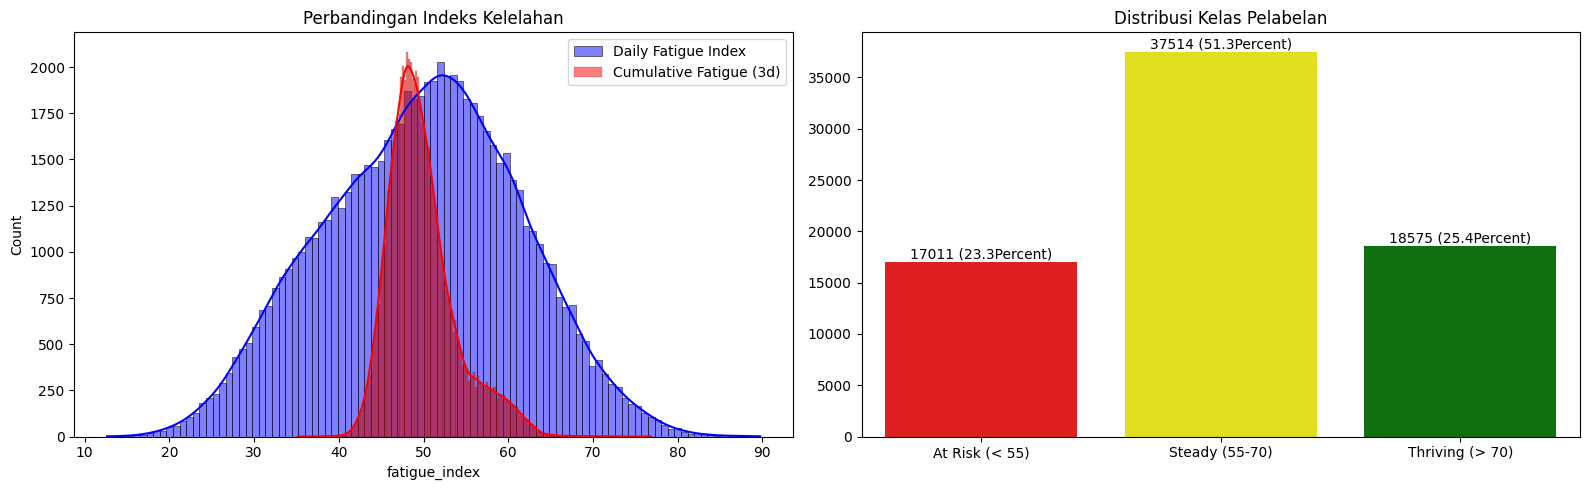

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

#visualisasi fitur baru sebelum vs sesudah rolling sum
sns.histplot(data=df, x='fatigue_index', color='blue', alpha=0.5, label='Daily Fatigue Index', kde=True, ax=ax[0])
sns.histplot(data=df, x='cumulative_fatigue', color='red', alpha=0.5, label='Cumulative Fatigue (3d)', kde=True, ax=ax[0])
ax[0].set_title('Perbandingan Indeks Kelelahan')
ax[0].legend()

#visualisasi distribusi kelas target klasifikasi untuk mendeteksi ketidakseimbangan kelas
label_counts = df[target_clf].value_counts().sort_index()
labels = ['At Risk (< 55)', 'Steady (55-70)', 'Thriving (> 70)']
sns.barplot(x=labels, y=label_counts.values, hue=labels, palette=['red', 'yellow', 'green'], ax=ax[1], legend=False)
ax[1].set_title('Distribusi Kelas Pelabelan')
for i, count in enumerate(label_counts.values):
    ax[1].text(i, count + 300, f"{count} ({count/len(df)*100:.1f}Percent)", ha='center')

plt.tight_layout()
plt.show()

##**5. Preprocessing Data (Anti Data Leakage)**

Tahap preprocessing dilakukan dengan aturan ketat agar tidak terjadi kebocoran data (*data leakage*).


###**5.1 Pembagian Data Secara Kronologis**

Dataset dibagi menjadi:
- Train Set (70%)
- Validation Set (15%)
- Test Set (15%)

Pembagian dilakukan berdasarkan urutan waktu setiap pengguna.

In [12]:
train_dfs, val_dfs, test_dfs = [], [], []
df = df.sort_values(by=['user_id', 'date'])

for user_id, group in df.groupby('user_id'):
    n = len(group)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)
    train_dfs.append(group.iloc[:n_train])
    val_dfs.append(group.iloc[n_train:n_train+n_val])
    test_dfs.append(group.iloc[n_train+n_val:])

train_df = pd.concat(train_dfs).reset_index(drop=True)
val_df = pd.concat(val_dfs).reset_index(drop=True)
test_df = pd.concat(test_dfs).reset_index(drop=True)

print(f"Ukuran subset: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Ukuran subset: Train=51100, Val=10900, Test=11100


###**5.2 Normalisasi Fitur**

Normalisasi menggunakan `MinMaxScaler` agar seluruh fitur memiliki rentang nilai yang konsisten.

Scaler hanya di-*fit* pada data train untuk mencegah data leakage.

In [13]:
feature_cols = [

    'is_weekend',
    'sleep_duration',
    'study_work_duration',
    'break_duration',
    'exercise_duration',
    'downtime_duration',
    'stress_level',
    'mood_score',
    'focus_score',
    'task_planned',
    'task_completed',
    'completion_ratio',
    'fatigue_index',
    'cumulative_fatigue',
]

#normalisasi fitur
feature_scaler = MinMaxScaler()
feature_scaler.fit(train_df[feature_cols])

#normalisasi target regresi
target_scaler = MinMaxScaler()
target_scaler.fit(train_df[[target_col]])

#transformasikan
train_features_scaled = feature_scaler.transform(train_df[feature_cols])
val_features_scaled = feature_scaler.transform(val_df[feature_cols])
test_features_scaled = feature_scaler.transform(test_df[feature_cols])

train_target_scaled = target_scaler.transform(train_df[[target_col]])
val_target_scaled = target_scaler.transform(val_df[[target_col]])
test_target_scaled = target_scaler.transform(test_df[[target_col]])

#ekspor scaler
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)
with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)

print("Penskalaan selesai. Scaler tersimpan.")

Penskalaan selesai. Scaler tersimpan.


###**5.3 Pembuatan Sequence 3D untuk LSTM**

Data diubah menjadi bentuk tensor 3D:

```text
[samples, time_steps, features]
```

menggunakan metode sliding window selama 7 hari.

In [14]:
def generate_sequences_for_split(df_split, feat_scaler, targ_scaler, window_size=7):
    X_list, y_reg_list, y_clf_list = [], [], []
    for user_id, group in df_split.groupby('user_id'):
        feats = feat_scaler.transform(group[feature_cols])
        targ_reg = targ_scaler.transform(group[[target_col]]).flatten()
        targ_clf = tf.keras.utils.to_categorical(group[target_clf].values, num_classes=3)

        #target mengestimasi skor produktivitas mingguan
        for i in range(len(group) - window_size + 1):
            X_list.append(feats[i : i + window_size])
            y_reg_list.append(targ_reg[i + window_size - 1])
            y_clf_list.append(targ_clf[i + window_size - 1])

    return np.array(X_list), np.array(y_reg_list), np.array(y_clf_list)

X_train, y_train_reg, y_train_clf = generate_sequences_for_split(train_df, feature_scaler, target_scaler)
X_val, y_val_reg, y_val_clf = generate_sequences_for_split(val_df, feature_scaler, target_scaler)
X_test, y_test_reg, y_test_clf = generate_sequences_for_split(test_df, feature_scaler, target_scaler)

#cast ke float32
X_train, y_train_reg, y_train_clf = X_train.astype(np.float32), y_train_reg.astype(np.float32), y_train_clf.astype(np.float32)
X_val, y_val_reg, y_val_clf = X_val.astype(np.float32), y_val_reg.astype(np.float32), y_val_clf.astype(np.float32)
X_test, y_test_reg, y_test_clf = X_test.astype(np.float32), y_test_reg.astype(np.float32), y_test_clf.astype(np.float32)

print("Dimensi akhir tensor 3D:")
print("Train X:", X_train.shape, "y_reg:", y_train_reg.shape, "y_clf:", y_train_clf.shape)
print("Val X:", X_val.shape, "y_reg:", y_val_reg.shape, "y_clf:", y_val_clf.shape)
print("Test X:", X_test.shape, "y_reg:", y_test_reg.shape, "y_clf:", y_test_clf.shape)

Dimensi akhir tensor 3D:
Train X: (50500, 7, 14) y_reg: (50500,) y_clf: (50500, 3)
Val X: (10300, 7, 14) y_reg: (10300,) y_clf: (10300, 3)
Test X: (10500, 7, 14) y_reg: (10500,) y_clf: (10500, 3)


##**6. Perancangan Model Multi-Output LSTM**

Tahap pembangunan arsitektur deep learning.

Model dirancang untuk menghasilkan:
- output regresi,
- dan output klasifikasi

dalam satu model secara bersamaan.

##**6.1 Konfigurasi Model**

Menentukan:
- struktur model,
- jumlah neuron,
- activation function,
- dan parameter pelatihan.

###**6.2 Arsitektur Utama Model**

Model menggunakan:
- LSTM Layer
- Attention Layer
- Dense Layer
- Multi-Output Prediction

###**6.3 Integrasi Custom Attention Layer**

Attention Layer membantu model fokus pada informasi waktu yang paling penting dalam sequence pengguna.


In [19]:
#layer Attention Kustom dengan dukungan serialisasi penuh
@tf.keras.utils.register_keras_serializable(package="Custom")
class CustomAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(CustomAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(CustomAttention, self).build(input_shape)

    def call(self, inputs):
        #inputs shape: (batch_size, time_steps, features)
        e = tf.tensordot(inputs, self.W, axes=[-1, 0]) + self.b
        e = tf.nn.tanh(e)
        alpha = tf.nn.softmax(e, axis=1) # (batch_size, time_steps, 1)
        context = inputs * alpha
        context = tf.reduce_sum(context, axis=1) # (batch_size, features)
        return context

    def get_config(self):
        return super(CustomAttention, self).get_config()

#pembangunan model melalui Functional API
inputs = layers.Input(shape=(7, 14), name="input_layer")
lstm_out = layers.LSTM(64, return_sequences=True, name="lstm_layer")(inputs)
attention_out = CustomAttention(name="attention_layer")(lstm_out)
dense_shared = layers.Dense(32, activation="relu", name="dense_shared")(attention_out)

#output 1: Regresi Skor Produktivitas (Sigmoid karena target [0,1])
out_reg = layers.Dense(1, activation="sigmoid", name="out_regression")(dense_shared)

#output 2: Klasifikasi 3 Kategori (Softmax)
out_clf = layers.Dense(3, activation="softmax", name="out_classification")(dense_shared)

model = tf.keras.Model(inputs=inputs, outputs=[out_reg, out_clf], name="multi_output_lstm")
model.summary()

Model: "multi_output_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer (LSTM)   │ (None, 7, 64)     │     20,224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 64)        │         71 │ lstm_layer[0][0]  │
│ (CustomAttention)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 32)        │      2,080 │ attention_layer[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_regression      │ (None, 1)         │         33 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_classification  │ (None, 3)         │         99 │ dense_shared[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,507 (87.92 KB)

 Trainable params: 22,507 (87.92 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss={
        'out_regression': 'mse',
        'out_classification': 'categorical_crossentropy'
    },
    loss_weights={
        'out_regression': 1.0,
        'out_classification': 0.5
    },
    metrics={
        'out_regression': 'mae',
        'out_classification': 'accuracy'
    }
)

##**7. Pelatihan Model dan Monitoring**

Tahap training model menggunakan custom training loop berbasis `tf.GradientTape`.

### **7.1 Input Pipeline dengan tf.data.Dataset**

Pipeline data digunakan agar proses training lebih cepat dan efisien.

###**7.2 TensorBoard dan Monitoring**

TensorBoard digunakan untuk memantau:
- loss,
- MAE,
- dan akurasi model

selama proses pelatihan.

###**7.3 Custom Training Loop**

Training dilakukan secara manual menggunakan:
- GradientTape,
- custom loss,
- dan custom callback.


In [21]:
class EarlyStoppingLRCallback(tf.keras.callbacks.Callback):
    def __init__(self, model, optimizer, patience=5, lr_patience=5,
                 lr_factor=0.5, lr_min=1e-6, save_path='best_model.keras'):
        super().__init__()
        self.tracked_model = model
        self.optimizer = optimizer
        self.patience = patience
        self.lr_patience = lr_patience
        self.lr_factor = lr_factor
        self.lr_min = lr_min
        self.save_path = save_path
        self.best_val_loss = float('inf')
        self.wait = 0
        self.lr_wait = 0
        self.stop_training = False

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        if val_loss is None:
            return

        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.wait = 0
            self.lr_wait = 0
            self.tracked_model.save(self.save_path)
            print(f"   [Callback] Model terbaik disimpan. val_loss: {val_loss:.4f}")
        else:
            self.wait += 1
            self.lr_wait += 1
            print(f"   [Callback] Tidak ada improvement. Patience: {self.wait}/{self.patience}")

            if self.lr_wait >= self.lr_patience:
                current_lr = float(self.optimizer.learning_rate)
                new_lr = max(current_lr * self.lr_factor, self.lr_min)
                if new_lr < current_lr:
                    self.optimizer.learning_rate.assign(new_lr)
                    print(f"   [Callback] LR turun → {new_lr:.6f}")
                self.lr_wait = 0

            if self.wait >= self.patience:
                self.stop_training = True
                print(f"   [Callback] Early stopping di epoch {epoch+1}. "
                      f"Val_loss tidak membaik selama {self.patience} epoch.")

In [24]:
#pipeline tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, {"out_regression": y_train_reg, "out_classification": y_train_clf}))
train_ds = train_ds.shuffle(10000).batch(128).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, {"out_regression": y_val_reg, "out_classification": y_val_clf}))
val_ds = val_ds.batch(128).prefetch(tf.data.AUTOTUNE)

#define optimizer dan metrik
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
alpha_loss = tf.constant(1.0, dtype=tf.float32)
beta_loss = tf.constant(1.0, dtype=tf.float32)

train_mae = tf.keras.metrics.MeanAbsoluteError()
train_acc = tf.keras.metrics.CategoricalAccuracy()
val_mae = tf.keras.metrics.MeanAbsoluteError()
val_acc = tf.keras.metrics.CategoricalAccuracy()

@tf.function
def train_step(x, y_reg, y_clf):
    with tf.GradientTape() as tape:
        y_pred_reg, y_pred_clf = model(x, training=True)
        y_pred_reg_sq = tf.squeeze(y_pred_reg, axis=-1)
        loss_reg = tf.reduce_mean(tf.square(y_reg - y_pred_reg_sq))
        loss_clf = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_clf, y_pred_clf))
        loss_total = alpha_loss * loss_reg + beta_loss * loss_clf

    gradients = tape.gradient(loss_total, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_mae.update_state(y_reg, y_pred_reg_sq)
    train_acc.update_state(y_clf, y_pred_clf)
    return loss_total, loss_reg, loss_clf

@tf.function
def val_step(x, y_reg, y_clf):
    y_pred_reg, y_pred_clf = model(x, training=False)
    y_pred_reg_sq = tf.squeeze(y_pred_reg, axis=-1)
    loss_reg = tf.reduce_mean(tf.square(y_reg - y_pred_reg_sq))
    loss_clf = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_clf, y_pred_clf))
    loss_total = alpha_loss * loss_reg + beta_loss * loss_clf

    val_mae.update_state(y_reg, y_pred_reg_sq)
    val_acc.update_state(y_clf, y_pred_clf)
    return loss_total, loss_reg, loss_clf

callback = EarlyStoppingLRCallback(model=model, optimizer=optimizer)

#tensorboard writer
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_writer = tf.summary.create_file_writer(f'logs/gradient_tape/{current_time}/train')
val_writer = tf.summary.create_file_writer(f'logs/gradient_tape/{current_time}/val')

#custom training loop
epochs = 50
best_val_loss = float('inf')
history_metrics = {'train_loss': [], 'train_mae': [], 'train_acc': [], 'val_loss': [], 'val_mae': [], 'val_acc': []}

for epoch in range(epochs):
    train_mae.reset_state()
    train_acc.reset_state()
    val_mae.reset_state()
    val_acc.reset_state()

    total_train_loss = 0.0
    train_batches = 0
    for x_batch, y_batch in train_ds:
        loss_total, _, _ = train_step(x_batch, y_batch['out_regression'], y_batch['out_classification'])
        total_train_loss += loss_total.numpy()
        train_batches += 1
    avg_train_loss = total_train_loss / train_batches

    total_val_loss = 0.0
    val_batches = 0
    for x_batch_val, y_batch_val in val_ds:
        val_loss_total, _, _ = val_step(x_batch_val, y_batch_val['out_regression'], y_batch_val['out_classification'])
        total_val_loss += val_loss_total.numpy()
        val_batches += 1
    avg_val_loss = total_val_loss / val_batches

    #simpan history metrik
    history_metrics['train_loss'].append(avg_train_loss)
    history_metrics['train_mae'].append(train_mae.result().numpy())
    history_metrics['train_acc'].append(train_acc.result().numpy())
    history_metrics['val_loss'].append(avg_val_loss)
    history_metrics['val_mae'].append(val_mae.result().numpy())
    history_metrics['val_acc'].append(val_acc.result().numpy())

    #log ke tensorBoard
    with train_writer.as_default():
        tf.summary.scalar('loss', avg_train_loss, step=epoch)
        tf.summary.scalar('mae', train_mae.result(), step=epoch)
        tf.summary.scalar('accuracy', train_acc.result(), step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('loss', avg_val_loss, step=epoch)
        tf.summary.scalar('mae', val_mae.result(), step=epoch)
        tf.summary.scalar('accuracy', val_acc.result(), step=epoch)

    print(f"Epoch {epoch+1:02d}/{epochs} - loss: {avg_train_loss:.4f} - mae: {train_mae.result().numpy():.4f} - acc: {train_acc.result().numpy():.4f} | val_loss: {avg_val_loss:.4f} - val_mae: {val_mae.result().numpy():.4f} - val_acc: {val_acc.result().numpy():.4f}")

    callback.on_epoch_end(epoch, logs={'val_loss': avg_val_loss})

    if callback.stop_training:
        break

print(f"\nTraining selesai. Best val_loss: {callback.best_val_loss:.4f}")

Epoch 01/50 - loss: 0.0494 - mae: 0.0094 - acc: 0.9800 | val_loss: 0.0465 - val_mae: 0.0096 - val_acc: 0.9791
   [Callback] Model terbaik disimpan. val_loss: 0.0465
Epoch 02/50 - loss: 0.0457 - mae: 0.0086 - acc: 0.9813 | val_loss: 0.0409 - val_mae: 0.0097 - val_acc: 0.9841
   [Callback] Model terbaik disimpan. val_loss: 0.0409
Epoch 03/50 - loss: 0.0443 - mae: 0.0091 - acc: 0.9814 | val_loss: 0.0384 - val_mae: 0.0064 - val_acc: 0.9842
   [Callback] Model terbaik disimpan. val_loss: 0.0384
Epoch 04/50 - loss: 0.0462 - mae: 0.0090 - acc: 0.9804 | val_loss: 0.0412 - val_mae: 0.0097 - val_acc: 0.9818
   [Callback] Tidak ada improvement. Patience: 1/5
Epoch 05/50 - loss: 0.0438 - mae: 0.0086 - acc: 0.9816 | val_loss: 0.0413 - val_mae: 0.0075 - val_acc: 0.9815
   [Callback] Tidak ada improvement. Patience: 2/5
Epoch 06/50 - loss: 0.0403 - mae: 0.0084 - acc: 0.9838 | val_loss: 0.0298 - val_mae: 0.0085 - val_acc: 0.9917
   [Callback] Model terbaik disimpan. val_loss: 0.0298
Epoch 07/50 - loss

##**8. Evaluasi Kinerja Model**

Tahap evaluasi dilakukan menggunakan data test yang belum pernah dilihat model sebelumnya.

###**8.1 Evaluasi Akurasi dan MAE**

Target performa model:
- Accuracy ≥ 85%
- MAE ≤ 0.02


In [25]:
#memuat kembali model terbaik hasil latihan
best_model = tf.keras.models.load_model('best_model.keras', custom_objects={'CustomAttention': CustomAttention})

#prediksi pada data test yang benar-benar baru
test_pred_reg, test_pred_clf = best_model.predict(X_test, verbose=0)
test_pred_reg_sq = test_pred_reg.squeeze()

#evaluasi metrik targets
test_mae_metric = tf.keras.metrics.MeanAbsoluteError()
test_mae_metric.update_state(y_test_reg, test_pred_reg_sq)
test_mae_val = test_mae_metric.result().numpy()

test_mse = np.mean((y_test_reg - test_pred_reg_sq) ** 2)
test_rmse = np.sqrt(test_mse)

test_acc_metric = tf.keras.metrics.CategoricalAccuracy()
test_acc_metric.update_state(y_test_clf, test_pred_clf)
test_acc_val = test_acc_metric.result().numpy()

print("HASIL PENGUJIAN AKHIR MODEL DATA TEST")
print(f"Akurasi Klasifikasi : {test_acc_val * 100:.2f}% (Target: >= 85%)")
print(f"Regression MAE      : {test_mae_val:.4f} (Target: <= 0.02)")
print(f"Regression RMSE     : {test_rmse:.4f}")

if test_acc_val >= 0.85 and test_mae_val <= 0.02:
    print("STATUS: TARGET KINERJA BERHASIL DIPENUHI!")
else:
    print("STATUS: TARGET KINERJA GAGAL DIPENUHI. SILAKAN SESUAIKAN KEMBALI HYPERPARAMETER.")

HASIL PENGUJIAN AKHIR MODEL DATA TEST
Akurasi Klasifikasi : 98.91% (Target: >= 85%)
Regression MAE      : 0.0084 (Target: <= 0.02)
Regression RMSE     : 0.0109
STATUS: TARGET KINERJA BERHASIL DIPENUHI!


In [29]:
y_true_clf = np.argmax(y_test_clf, axis=1)
y_pred_clf_label = np.argmax(test_pred_clf, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_clf, y_pred_clf_label,
      target_names=['At risk', 'Steady', 'Thriving']))


Classification Report:
              precision    recall  f1-score   support

     At risk       1.00      0.98      0.99      2377
      Steady       0.99      0.99      0.99      5466
    Thriving       0.99      0.99      0.99      2657

    accuracy                           0.99     10500
   macro avg       0.99      0.99      0.99     10500
weighted avg       0.99      0.99      0.99     10500



###**8.2 Visualisasi Hasil Evaluasi**

Visualisasi meliputi:
- kurva loss,
- kurva akurasi,
- dan confusion matrix.

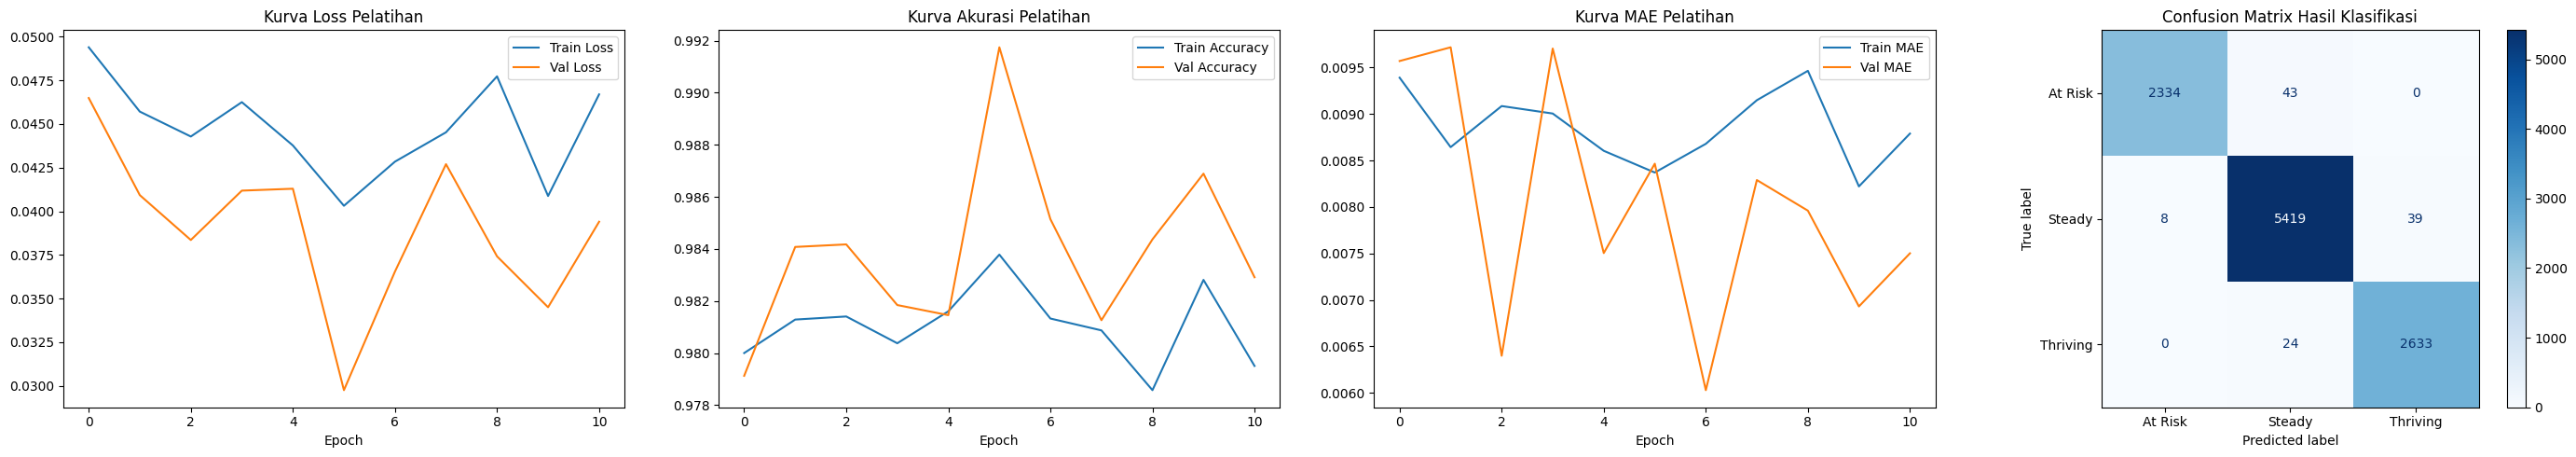

In [33]:
#visualisasi kurva pelatihan dan confusion matrix
epochs_range = range(len(history_metrics['train_loss']))
fig, ax = plt.subplots(1, 4, figsize=(28, 5))

#kurva loss
ax[0].plot(epochs_range, history_metrics['train_loss'], label='Train Loss')
ax[0].plot(epochs_range, history_metrics['val_loss'], label='Val Loss')
ax[0].set_title('Kurva Loss Pelatihan')
ax[0].set_xlabel('Epoch')
ax[0].legend()

#kurva akurasi
ax[1].plot(epochs_range, history_metrics['train_acc'], label='Train Accuracy')
ax[1].plot(epochs_range, history_metrics['val_acc'], label='Val Accuracy')
ax[1].set_title('Kurva Akurasi Pelatihan')
ax[1].set_xlabel('Epoch')
ax[1].legend()

ax[2].plot(epochs_range, history_metrics['train_mae'], label='Train MAE')
ax[2].plot(epochs_range, history_metrics['val_mae'], label='Val MAE')
ax[2].set_title('Kurva MAE Pelatihan')
ax[2].set_xlabel('Epoch')
ax[2].legend()

#confusion matrix
y_test_true_classes = np.argmax(y_test_clf, axis=1)
y_test_pred_classes = np.argmax(test_pred_clf, axis=1)
cm = confusion_matrix(y_test_true_classes, y_test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['At Risk', 'Steady', 'Thriving'])
disp.plot(cmap='Blues', ax=ax[3])  # ← fix di sini
ax[3].set_title('Confusion Matrix Hasil Klasifikasi')

plt.tight_layout()
plt.show()

**Analisis Visualisasi**

1. Kurva Loss

Val Loss (orange) selalu di bawah Train Loss → model tidak overfitting
Tren keduanya menurun meski fluktuatif — wajar karena hanya 11 epoch

2. Kurva Akurasi

Val Accuracy fluktuatif tapi berkisar 98–99% → konsisten tinggi
Train Accuracy sedikit lebih rendah dari val → tanda generalisasi baik

3. Kurva MAE

Kedua MAE sangat rendah (0.006–0.0095) → jauh di bawah target 0.02
Pola fluktuatif normal karena epoch sedikit (early stopping di epoch 11)

##**9. Deployment dan Simulasi Produksi**

Tahap akhir untuk menyimpan model dan melakukan simulasi prediksi pada data baru.

###**9.1 Export Model**

Model terbaik disimpan dalam format `.keras` agar dapat digunakan kembali pada aplikasi produksi.

In [34]:
#ekspor model secara penuh ke dalam format .keras
best_model.save('final_lstm_multioutput.keras')
print("Model akhir berhasil disimpan ke 'final_lstm_multioutput.keras'")

Model akhir berhasil disimpan ke 'final_lstm_multioutput.keras'


###**9.2 Simulasi Prediksi End-to-End**

Simulasi dilakukan menggunakan data aktivitas pengguna selama 7 hari untuk memprediksi:
- skor produktivitas,
- kategori kondisi pengguna,
- dan rekomendasi kondisi pengguna.

In [64]:
#inference 5 sampel random dari test set
import random
indices = random.sample(range(len(X_test)), 5)

print("Inference 5 Sampel Random dari Data Test \n")
for idx in indices:
    sample = X_test[idx:idx+1]
    pred_reg, pred_clf = best_model.predict(sample, verbose=0)
    reg_score = target_scaler.inverse_transform(pred_reg)[0][0]

    if reg_score < 55.0:
        category = 'At Risk'
    elif reg_score <= 70.0:
        category = 'Steady'
    else:
        category = 'Thriving'

    true_reg = target_scaler.inverse_transform([[y_test_reg[idx]]])[0][0]
    true_clf = ['At Risk', 'Steady', 'Thriving'][np.argmax(y_test_clf[idx])]
    match = "OK" if category == true_clf else "!"

    print(f"Index {idx} {match}")
    print(f"  Ground Truth : {true_reg:.2f} ({true_clf})")
    print(f"  Prediksi     : {reg_score:.2f} ({category})")
    print(f"  Prob         : [At Risk: {pred_clf[0][0]:.4f}, Steady: {pred_clf[0][1]:.4f}, Thriving: {pred_clf[0][2]:.4f}]")

    confidence = np.max(pred_clf[0]) * 100
    print(f"  Confidence   : {confidence:.2f}%\n")

Inference 5 Sampel Random dari Data Test 

Index 4638 OK
  Ground Truth : 80.28 (Thriving)
  Prediksi     : 80.67 (Thriving)
  Prob         : [At Risk: 0.0000, Steady: 0.0000, Thriving: 1.0000]
  Confidence   : 100.00%

Index 2308 OK
  Ground Truth : 69.10 (Steady)
  Prediksi     : 69.41 (Steady)
  Prob         : [At Risk: 0.0000, Steady: 0.9759, Thriving: 0.0241]
  Confidence   : 97.59%

Index 1753 OK
  Ground Truth : 74.55 (Thriving)
  Prediksi     : 75.05 (Thriving)
  Prob         : [At Risk: 0.0000, Steady: 0.0000, Thriving: 1.0000]
  Confidence   : 100.00%

Index 8171 OK
  Ground Truth : 61.66 (Steady)
  Prediksi     : 62.42 (Steady)
  Prob         : [At Risk: 0.0000, Steady: 1.0000, Thriving: 0.0000]
  Confidence   : 100.00%

Index 7050 OK
  Ground Truth : 68.92 (Steady)
  Prediksi     : 69.61 (Steady)
  Prob         : [At Risk: 0.0000, Steady: 0.9820, Thriving: 0.0180]
  Confidence   : 98.20%



In [46]:
feature_cols = [
    'is_weekend', 'sleep_duration', 'study_work_duration', 'break_duration',
    'exercise_duration', 'downtime_duration', 'stress_level', 'mood_score',
    'focus_score', 'task_planned', 'task_completed', 'completion_ratio',
    'fatigue_index', 'cumulative_fatigue'
]

def simulate_inference(raw_7day_logs, feat_scaler_path='feature_scaler.pkl', target_scaler_path='target_scaler.pkl', model_path='best_model.keras'):
    with open(feat_scaler_path, 'rb') as f:
        fs = pickle.load(f)
    with open(target_scaler_path, 'rb') as f:
        ts = pickle.load(f)

    model_inf = tf.keras.models.load_model(model_path, custom_objects={'CustomAttention': CustomAttention}, compile=False)

    df_raw = pd.DataFrame(raw_7day_logs)

    df_raw['fatigue_index'] = (
    (df_raw['stress_level'] / 8.0)        * 40 +
    (df_raw['downtime_duration'] / 11.21) * 30 +
    (df_raw['study_work_duration'] / 17.405)  * 30
    ).clip(0, 100).round(2)

    df_raw['cumulative_fatigue'] = (
        df_raw['fatigue_index'].ewm(alpha=1-0.9, adjust=False).mean()  # alpha=0.1
    ).clip(0, 100).round(2)

    df_raw['completion_ratio'] = (
    df_raw['task_completed'] / df_raw['task_planned']
    ).round(3)


    df_features = df_raw[feature_cols]

    feats_scaled = fs.transform(df_features)
    feats_scaled_3d = np.expand_dims(feats_scaled, axis=0)

    pred_reg, pred_clf = model_inf.predict(feats_scaled_3d, verbose=0)

    reg_score_original = ts.inverse_transform(pred_reg)[0][0]

    predicted_class_idx = np.argmax(pred_clf[0])
    classes = ['At Risk', 'Steady', 'Thriving']
    predicted_class_name = classes[predicted_class_idx]

    return reg_score_original, predicted_class_name, pred_clf[0]


# 1. Kondisi 1: PRIMA & SEHAT (Thriving)
logs_thriving = []
for i in range(7):
    logs_thriving.append({
        'sleep_duration': 8.0, 'study_work_duration': 5.0,
        'break_duration': 1.5, 'exercise_duration': 45, 'downtime_duration': 2.0,
        'stress_level': 2, 'mood_score': 9, 'focus_score': 9,
        'task_planned': 5, 'task_completed': 5,
        'is_weekend': 1 if (i in [5, 6]) else 0
    })

# 2. Kondisi 2: STABIL & SEIMBANG (Steady)
logs_steady = []
for i in range(7):
    logs_steady.append({
        'sleep_duration': 6.5, 'study_work_duration': 7.5,
        'break_duration': 0.5, 'exercise_duration': 20, 'downtime_duration': 1.5,
        'stress_level': 5, 'mood_score': 6, 'focus_score': 7,
        'task_planned': 6, 'task_completed': 4,
        'is_weekend': 1 if (i in [5, 6]) else 0
    })

# 3. Kondisi 3: LELAH & BURNOUT (At Risk)
logs_at_risk = []
for i in range(7):
    logs_at_risk.append({
        'sleep_duration': 4.5, 'study_work_duration': 10.0,
        'break_duration': 0.15, 'exercise_duration': 0, 'downtime_duration': 0.5,
        'stress_level': 9, 'mood_score': 2, 'focus_score': 3,
        'task_planned': 8, 'task_completed': 2,
        'is_weekend': 1 if (i in [5, 6]) else 0
    })

scenarios = {
    "Kondisi 1: PRIMA & SEHAT (Thriving)": logs_thriving,
    "Kondisi 2: STABIL & SEIMBANG (Steady)": logs_steady,
    "Kondisi 3: LELAH & BURNOUT (At Risk)": logs_at_risk
}


print("SIMULASI INFERENSI DIGITAL TWIN UNTUK MENGEVALUASI PRODUKTIVITAS MINGGUAN\n")
for sc_name, sc_logs in scenarios.items():
    score, category, probs = simulate_inference(sc_logs)
    print(f"{sc_name}:")
    print(f"   -> Prediksi Skor Produktivitas : {score:.2f}")
    print(f"   -> Prediksi Kategori Kondisi   : {category}")
    print(f"   -> Probabilitas Distribusi     : [At Risk: {probs[0]:.4f}, Steady: {probs[1]:.4f}, Thriving: {probs[2]:.4f}]")
    if category == 'Thriving':
        print("   -> Rekomendasi: Pertahankan pola kerja dan gaya hidup yang sangat baik ini!\n")
    elif category == 'Steady':
        print("   -> Rekomendasi: Anda dalam kondisi stabil. Jaga keseimbangan antara bekerja dan beristirahat.\n")
    else:
        print("   -> Rekomendasi: PERINGATAN! Tingkat kelelahan Anda kritis. Kurangi beban kerja dan tidur yang cukup!\n")

SIMULASI INFERENSI DIGITAL TWIN UNTUK MENGEVALUASI PRODUKTIVITAS MINGGUAN

Kondisi 1: PRIMA & SEHAT (Thriving):
   -> Prediksi Skor Produktivitas : 80.53
   -> Prediksi Kategori Kondisi   : Thriving
   -> Probabilitas Distribusi     : [At Risk: 0.0000, Steady: 0.0000, Thriving: 1.0000]
   -> Rekomendasi: Pertahankan pola kerja dan gaya hidup yang sangat baik ini!

Kondisi 2: STABIL & SEIMBANG (Steady):
   -> Prediksi Skor Produktivitas : 58.33
   -> Prediksi Kategori Kondisi   : Steady
   -> Probabilitas Distribusi     : [At Risk: 0.0002, Steady: 0.9998, Thriving: 0.0000]
   -> Rekomendasi: Anda dalam kondisi stabil. Jaga keseimbangan antara bekerja dan beristirahat.

Kondisi 3: LELAH & BURNOUT (At Risk):
   -> Prediksi Skor Produktivitas : 37.19
   -> Prediksi Kategori Kondisi   : At Risk
   -> Probabilitas Distribusi     : [At Risk: 1.0000, Steady: 0.0000, Thriving: 0.0000]
   -> Rekomendasi: PERINGATAN! Tingkat kelelahan Anda kritis. Kurangi beban kerja dan tidur yang cukup!



In [53]:
# Hari ke-7 sama persis untuk semua skenario
day7 = {
    'sleep_duration': 7.0, 'study_work_duration': 6.0,
    'break_duration': 1.0, 'exercise_duration': 30, 'downtime_duration': 1.5,
    'stress_level': 4, 'mood_score': 7, 'focus_score': 7,
    'task_planned': 5, 'task_completed': 4,
    'is_weekend': 0
}

# Skenario A: 6 hari sebelumnya BURUK → hari ke-7 normal
logs_A = []
for i in range(6):
    logs_A.append({
        'sleep_duration': 4.0, 'study_work_duration': 11.0,
        'break_duration': 0.1, 'exercise_duration': 0, 'downtime_duration': 0.3,
        'stress_level': 9, 'mood_score': 2, 'focus_score': 3,
        'task_planned': 8, 'task_completed': 1,
        'is_weekend': 1 if (i in [5, 6]) else 0
    })
logs_A.append(day7)  # hari ke-7 sama

# Skenario B: 6 hari sebelumnya PRIMA → hari ke-7 normal
logs_B = []
for i in range(6):
    logs_B.append({
        'sleep_duration': 8.5, 'study_work_duration': 4.0,
        'break_duration': 2.0, 'exercise_duration': 60, 'downtime_duration': 3.0,
        'stress_level': 1, 'mood_score': 10, 'focus_score': 10,
        'task_planned': 5, 'task_completed': 5,
        'is_weekend': 1 if (i in [5, 6]) else 0
    })
logs_B.append(day7)  # hari ke-7 sama

score_A, cat_A, probs_A = simulate_inference(logs_A)
score_B, cat_B, probs_B = simulate_inference(logs_B)

print("TEMPORAL ABLATION TEST\n")
print(f"Skenario A (6 hari BURUK + hari ke-7 normal):")
print(f"   Skor: {score_A:.2f} | Kategori: {cat_A}")
print(f"   Prob: [At Risk: {probs_A[0]:.4f}, Steady: {probs_A[1]:.4f}, Thriving: {probs_A[2]:.4f}]\n")

print(f"Skenario B (6 hari PRIMA + hari ke-7 normal):")
print(f"   Skor: {score_B:.2f} | Kategori: {cat_B}")
print(f"   Prob: [At Risk: {probs_B[0]:.4f}, Steady: {probs_B[1]:.4f}, Thriving: {probs_B[2]:.4f}]\n")

if score_A != score_B:
    print("Model TERBUKTI belajar dari keseluruhan 7 hari!")
    print(f"   Selisih skor: {abs(score_A - score_B):.2f} poin")
else:
    print("Model kemungkinan hanya memperhatikan hari terakhir.")

TEMPORAL ABLATION TEST

Skenario A (6 hari BURUK + hari ke-7 normal):
   Skor: 42.27 | Kategori: At Risk
   Prob: [At Risk: 1.0000, Steady: 0.0000, Thriving: 0.0000]

Skenario B (6 hari PRIMA + hari ke-7 normal):
   Skor: 79.53 | Kategori: Thriving
   Prob: [At Risk: 0.0000, Steady: 0.0000, Thriving: 1.0000]

Model TERBUKTI belajar dari keseluruhan 7 hari!
   Selisih skor: 37.26 poin


In [55]:
print(type(shap_values))
print(len(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
5
(5, 98, 4)


(5, 98)


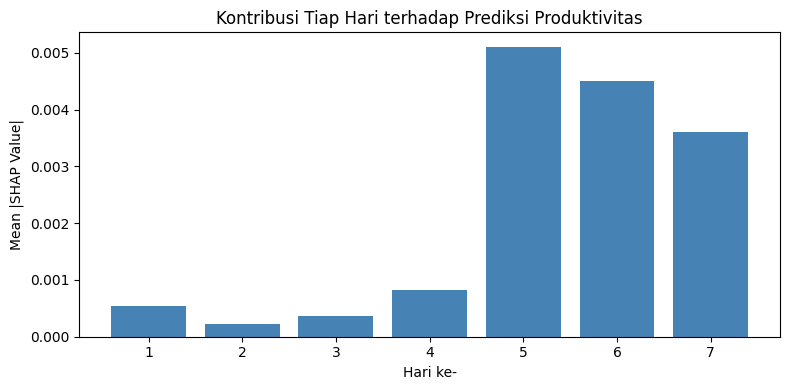


Kontribusi per hari:
  Hari 1: 0.000541 
  Hari 2: 0.000229 
  Hari 3: 0.000361 
  Hari 4: 0.000818 
  Hari 5: 0.005107 ← terbesar
  Hari 6: 0.004506 
  Hari 7: 0.003605 


In [57]:
import shap

def model_predict_wrapper(x_2d):
    x_3d = x_2d.reshape(-1, 7, 14)
    pred_reg, pred_clf = best_model.predict(x_3d, verbose=0)
    return np.hstack([pred_reg, pred_clf])  # shape (N, 4)

background = X_test[:100].reshape(100, 7*14)
explainer = shap.KernelExplainer(model_predict_wrapper, background)

shap_reg = shap_values[:, :, 0]  # shape (5, 98)
print(shap_reg.shape)

shap_per_day = shap_reg.reshape(5, 7, 14)  # shape (5, 7, 14)
mean_shap_per_day = np.abs(shap_per_day).mean(axis=(0, 2))  # rata2 per hari → shape (7,)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 8), mean_shap_per_day, color='steelblue')
plt.xlabel('Hari ke-')
plt.ylabel('Mean |SHAP Value|')
plt.title('Kontribusi Tiap Hari terhadap Prediksi Produktivitas')
plt.xticks(range(1, 8))
plt.tight_layout()
plt.show()

print("\nKontribusi per hari:")
for i, v in enumerate(mean_shap_per_day):
    marker = '← terbesar' if v == max(mean_shap_per_day) else ''
    print(f"  Hari {i+1}: {v:.6f} {marker}")

Model LSTM + Custom Attention terbukti menggunakan keseluruhan data 7 hari dalam membuat prediksi, dengan pola kontribusi yang meningkat mendekati hari terakhir — konsisten dengan sifat temporal LSTM dan desain cumulative_fatigue berbasis EWM.

##**10. Ablation Study: Baseline Dense (1 Hari) vs LSTM 7 Hari + Attention**

## Tujuan
Membuktikan secara ilmiah bahwa model LSTM yang memproses 7 hari data historis
memberikan performa yang lebih baik dibandingkan model yang hanya melihat data 1 hari terakhir.

## Desain Eksperimen

| Aspek | Baseline | LSTM 7 Hari |
|---|---|---|
| Input | 1 hari terakhir (shape: N, 14) | 7 hari sequence (shape: N, 7, 14) |
| Arsitektur | Dense 64 → Dense 32 | LSTM 64 + Custom Attention + Dense 32 |
| Temporal Awareness |  Tidak |  Ya |
| Parameter lain | Sama (data, target, metrik, optimizer, early stopping) | Sama |

## Controlled Variables
- Dataset: identik (train/val/test split sama)
- Target: regresi skor produktivitas + klasifikasi 3 kelas
- Optimizer: Adam (lr=0.001)
- Early stopping: patience=5
- Metrik: Accuracy, MAE, RMSE

In [52]:
X_train_baseline = X_train[:, -1, :]  # shape (N, 14)
X_val_baseline   = X_val[:, -1, :]
X_test_baseline  = X_test[:, -1, :]

inputs_b = layers.Input(shape=(14,), name="input_baseline")
dense1_b = layers.Dense(64, activation='relu', name="dense1_baseline")(inputs_b)
dense2_b = layers.Dense(32, activation='relu', name="dense2_baseline")(dense1_b)
out_reg_b = layers.Dense(1, activation='sigmoid', name="out_regression")(dense2_b)
out_clf_b = layers.Dense(3, activation='softmax', name="out_classification")(dense2_b)
baseline_model = tf.keras.Model(inputs=inputs_b, outputs=[out_reg_b, out_clf_b], name="baseline_dense")
baseline_model.summary()

optimizer_b = tf.keras.optimizers.Adam(learning_rate=0.001)

train_mae_b = tf.keras.metrics.MeanAbsoluteError()
train_acc_b = tf.keras.metrics.CategoricalAccuracy()
val_mae_b   = tf.keras.metrics.MeanAbsoluteError()
val_acc_b   = tf.keras.metrics.CategoricalAccuracy()

train_ds_b = tf.data.Dataset.from_tensor_slices((
    X_train_baseline,
    {"out_regression": y_train_reg, "out_classification": y_train_clf}
)).shuffle(10000).batch(128).prefetch(tf.data.AUTOTUNE)

val_ds_b = tf.data.Dataset.from_tensor_slices((
    X_val_baseline,
    {"out_regression": y_val_reg, "out_classification": y_val_clf}
)).batch(128).prefetch(tf.data.AUTOTUNE)

@tf.function
def train_step_b(x, y_reg, y_clf):
    with tf.GradientTape() as tape:
        y_pred_reg, y_pred_clf = baseline_model(x, training=True)
        y_pred_reg_sq = tf.squeeze(y_pred_reg, axis=-1)
        loss_reg = tf.reduce_mean(tf.square(y_reg - y_pred_reg_sq))
        loss_clf = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_clf, y_pred_clf))
        loss_total = loss_reg + loss_clf
    gradients = tape.gradient(loss_total, baseline_model.trainable_variables)
    optimizer_b.apply_gradients(zip(gradients, baseline_model.trainable_variables))
    train_mae_b.update_state(y_reg, y_pred_reg_sq)
    train_acc_b.update_state(y_clf, y_pred_clf)
    return loss_total

@tf.function
def val_step_b(x, y_reg, y_clf):
    y_pred_reg, y_pred_clf = baseline_model(x, training=False)
    y_pred_reg_sq = tf.squeeze(y_pred_reg, axis=-1)
    loss_reg = tf.reduce_mean(tf.square(y_reg - y_pred_reg_sq))
    loss_clf = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_clf, y_pred_clf))
    loss_total = loss_reg + loss_clf
    val_mae_b.update_state(y_reg, y_pred_reg_sq)
    val_acc_b.update_state(y_clf, y_pred_clf)
    return loss_total

best_val_loss_b = float('inf')
wait_b = 0
patience_b = 5
best_acc_b = 0.0
best_mae_b = 0.0

epochs = 50
print("TRAINING BASELINE MODEL\n")
for epoch in range(epochs):
    train_mae_b.reset_state()
    train_acc_b.reset_state()
    val_mae_b.reset_state()
    val_acc_b.reset_state()

    total_train_loss = 0.0
    train_batches = 0
    for x_batch, y_batch in train_ds_b:
        loss = train_step_b(x_batch, y_batch['out_regression'], y_batch['out_classification'])
        total_train_loss += loss.numpy()
        train_batches += 1

    total_val_loss = 0.0
    val_batches = 0
    for x_batch_val, y_batch_val in val_ds_b:
        loss = val_step_b(x_batch_val, y_batch_val['out_regression'], y_batch_val['out_classification'])
        total_val_loss += loss.numpy()
        val_batches += 1

    avg_train_loss = total_train_loss / train_batches
    avg_val_loss   = total_val_loss / val_batches

    print(f"Epoch {epoch+1:02d}/{epochs} - loss: {avg_train_loss:.4f} - mae: {train_mae_b.result().numpy():.4f} - acc: {train_acc_b.result().numpy():.4f} | val_loss: {avg_val_loss:.4f} - val_mae: {val_mae_b.result().numpy():.4f} - val_acc: {val_acc_b.result().numpy():.4f}")

    if avg_val_loss < best_val_loss_b:
        best_val_loss_b = avg_val_loss
        best_acc_b = val_acc_b.result().numpy()
        best_mae_b = val_mae_b.result().numpy()
        wait_b = 0
        baseline_model.save('best_baseline_model.keras')
        print(f"   [Callback] Model baseline terbaik disimpan. val_loss: {avg_val_loss:.4f}")
    else:
        wait_b += 1
        print(f"   [Callback] Tidak ada improvement. Patience: {wait_b}/{patience_b}")
        if wait_b >= patience_b:
            print(f"   [Callback] Early stopping di epoch {epoch+1}.")
            break

best_baseline = tf.keras.models.load_model('best_baseline_model.keras')
pred_reg_b, pred_clf_b = best_baseline.predict(X_test_baseline, verbose=0)
pred_reg_b_sq = pred_reg_b.squeeze()

mae_b = tf.keras.metrics.MeanAbsoluteError()
mae_b.update_state(y_test_reg, pred_reg_b_sq)
mae_val_b = mae_b.result().numpy()

acc_b = tf.keras.metrics.CategoricalAccuracy()
acc_b.update_state(y_test_clf, pred_clf_b)
acc_val_b = acc_b.result().numpy()

rmse_val_b = np.sqrt(np.mean((y_test_reg - pred_reg_b_sq) ** 2))

print("           HASIL ABLATION STUDY")
print(f"{'Metrik':<25} {'Baseline (1 hari)':<22} {'LSTM 7 hari + Attention'}")
print(f"{'Test Accuracy':<25} {acc_val_b*100:<22.2f} {'98.91'}")
print(f"{'Test MAE':<25} {mae_val_b:<22.4f} {'0.0084'}")
print(f"{'Test RMSE':<25} {rmse_val_b:<22.4f} {'0.0109'}")
print(f"{'Temporal Awareness':<25} {'Tidak':<22} {'Ya (LSTM + Attention)'}")
print(f"{'Arsitektur':<25} {'Dense (1 hari)':<22} {'LSTM + Attention (7 hari)'}")

print("\nKESIMPULAN ABLATION STUDY ")
acc_diff = (0.9891 - acc_val_b) * 100

Model: "baseline_dense"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_baseline      │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1_baseline     │ (None, 64)        │        960 │ input_baseline[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2_baseline     │ (None, 32)        │      2,080 │ dense1_baseline[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_regression      │ (None, 1)         │         33 │ dense2_baseline[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_classification  │ (None, 3)         │         99 │ dense2_baseline[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,172 (12.39 KB)

 Trainable params: 3,172 (12.39 KB)

 Non-trainable params: 0 (0.00 B)

TRAINING BASELINE MODEL

Epoch 01/50 - loss: 0.8578 - mae: 0.1019 - acc: 0.5808 | val_loss: 0.7871 - val_mae: 0.0904 - val_acc: 0.6223
   [Callback] Model baseline terbaik disimpan. val_loss: 0.7871
Epoch 02/50 - loss: 0.7918 - mae: 0.0904 - acc: 0.6163 | val_loss: 0.7704 - val_mae: 0.0883 - val_acc: 0.6265
   [Callback] Model baseline terbaik disimpan. val_loss: 0.7704
Epoch 03/50 - loss: 0.7841 - mae: 0.0893 - acc: 0.6221 | val_loss: 0.7708 - val_mae: 0.0892 - val_acc: 0.6278
   [Callback] Tidak ada improvement. Patience: 1/5
Epoch 04/50 - loss: 0.7818 - mae: 0.0890 - acc: 0.6237 | val_loss: 0.7643 - val_mae: 0.0875 - val_acc: 0.6284
   [Callback] Model baseline terbaik disimpan. val_loss: 0.7643
Epoch 05/50 - loss: 0.7823 - mae: 0.0890 - acc: 0.6218 | val_loss: 0.7620 - val_mae: 0.0872 - val_acc: 0.6313
   [Callback] Model baseline terbaik disimpan. val_loss: 0.7620
Epoch 06/50 - loss: 0.7811 - mae: 0.0887 - acc: 0.6259 | val_loss: 0.7608 - val_mae: 0.0873 - val_acc: 0.6324
   [Call

In [97]:
!pip install google-generativeai -q
import google.generativeai as genai

os.environ["GEMINI_API_KEY"] = "AQ.Ab8RN6Is3A-hFuxPU4tjCEpM1x05exo-UfMpJQz0rHC0F7bUEA"

class GenAIService:

    def __init__(self):
        self.api_key = os.environ.get("GEMINI_API_KEY")
        self.gemini_available = False

        if self.api_key:
            try:
                genai.configure(api_key=self.api_key)
                # self.gemini_model = genai.GenerativeModel('gemini-2.5-flash')
                self.gemini_model = genai.GenerativeModel('gemini-1.5-flash')
                self.gemini_available = True
                print("Gemini API configured successfully in GenAIService.")
            except Exception as e:
                print(f"Failed to initialize Gemini API in GenAIService: {e}")
        else:
            print("GEMINI_API_KEY not found in environment. Using rule-based fallback recommendations.")

    def get_recommendation(self, category: str, score: float, metrics: dict) -> str:
        if self.gemini_available:
            try:
                prompt = (
                    "Act as an analytical, professional, and objective AI Personal Health and Productivity Assistant.\n"
                    "You are provided with the user's activity data from the last 7 days as the basis for your analysis:\n\n"
                    "Activity Data for the Last 7 Days:\n"
                    f"- Weekly Productivity Score: {score:.2f}% (scale 0-100)\n"
                    f"- Current Condition Category: {category}\n"
                    f"- Average sleep: {metrics.get('avg_sleep', 7.0):.1f} hours (quality: {metrics.get('avg_sleep_quality', 7.0):.1f}/10)\n"
                    f"- Average work/study hours: {metrics.get('avg_work', 6.0):.1f} hours\n"
                    f"- Average stress level: {metrics.get('avg_stress', 5.0):.1f}/10\n"
                    f"- Average screen time: {metrics.get('avg_downtime', 4.0):.1f} hours\n"
                    f"- Fatigue accumulation: {metrics.get('last_fatigue', 2.0):.2f}\n\n"
                    "Write a recommendation report based on the following requirements:\n"
                    "- Use formal, professional, and analytical English.\n"
                    "- DO NOT use casual greetings, numbering, bullet points, markdown formatting, or any symbols.\n"
                    "- MUST consist of exactly 5 paragraphs, separated by double newlines (\\n\\n).\n\n"
                    "Paragraph 1: Explain the user's current condition based on the weekly productivity score.\n"
                    "Paragraph 2: Analyze the root causes based on the provided 7-day data summary.\n"
                    "Paragraph 3: Provide concrete, measurable activity recommendations to improve performance.\n"
                    "Paragraph 4: Provide an estimated productivity score prediction for tomorrow.\n"
                    "Paragraph 5: Provide a warning regarding burnout or fatigue risks if the current activity pattern persists."
                )

                response = self.gemini_model.generate_content(prompt)
                return response.text.strip()
            except Exception as e:
                print(f"Gemini API generation error: {e}. Falling back to rules.")
                self.gemini_available = False

        return self._get_fallback_recommendation(category, score, metrics)

    def _get_fallback_recommendation(self, category: str, score: float, metrics: dict) -> str:
        pred = min(100, score * 1.05) if category == 'Thriving' else (score * 0.95 if category == 'At Risk' else score)

        if category == 'Thriving':
            return (f"Current condition is prime (Thriving) with a weekly productivity score of {score:.2f}%. This performance reflects excellent stability over the past week.\n\n"
                    "This optimization is driven by ideal sleep duration and highly controlled stress management.\n\n"
                    "It is recommended to maintain the current operational pacing while consistently integrating active micro-breaks to preserve energy.\n\n"
                    f"The projected productivity score for tomorrow is {pred:.2f}%.\n\n"
                    "Continued adherence to this routine is crucial to stabilize energy levels and mitigate the risk of latent fatigue accumulation.")

        elif category == 'Steady':
            return (f"Current condition is stable (Steady) with a weekly productivity score of {score:.2f}%. Performance levels are currently well-maintained.\n\n"
                    "Prolonged screen exposure remains the primary factor potentially compromising physiological recovery.\n\n"
                    "Implementing a strict screen restriction for one hour before nocturnal rest is advised to improve sleep efficiency.\n\n"
                    f"The projected productivity score for tomorrow is {pred:.2f}%.\n\n"
                    "This preventive measure is essential to forestall stamina depletion and prevent a decline into higher-risk fatigue zones.")

        else:  # At Risk
            return (f"Current condition is high-risk (At Risk) with a weekly productivity score of {score:.2f}%. A decline in performance requires immediate intervention.\n\n"
                    "This indicator drop stems from significant fatigue accumulation, correlated with insufficient sleep and elevated stress indexes.\n\n"
                    "The immediate priority entails reducing computational workloads tonight and dedicating remaining hours to physiological recovery.\n\n"
                    f"The projected productivity score for tomorrow is {pred:.2f}%.\n\n"
                    "Disregarding these recovery signals will accelerate acute burnout and cause a substantial degradation in overall cognitive capabilities.")

In [ ]:
import random
indices = random.sample(range(len(X_test)), 1)

feature_cols = [
    'is_weekend', 'sleep_duration', 'study_work_duration', 'break_duration',
    'exercise_duration', 'downtime_duration', 'stress_level', 'mood_score',
    'focus_score', 'task_planned', 'task_completed', 'completion_ratio',
    'fatigue_index', 'cumulative_fatigue'
]
COL = {name: i for i, name in enumerate(feature_cols)}

# ── Compile inference function sekali di luar loop ───────────────
@tf.function(reduce_retracing=True)
def run_inference(x):
    return best_model(x, training=False)

print("Inference 1 Sampel Random dari Data Test\n")
for idx in indices:
    sample = tf.constant(X_test[idx:idx+1], dtype=tf.float32)

    pred_reg_tf, pred_clf_tf = run_inference(sample)
    pred_reg = pred_reg_tf.numpy()
    pred_clf = pred_clf_tf.numpy()

    reg_score = target_scaler.inverse_transform(pred_reg)[0][0]

    if reg_score < 55.0:
        category = 'At Risk'
    elif reg_score <= 70.0:
        category = 'Steady'
    else:
        category = 'Thriving'

    true_reg  = target_scaler.inverse_transform([[y_test_reg[idx]]])[0][0]
    true_clf  = ['At Risk', 'Steady', 'Thriving'][np.argmax(y_test_clf[idx])]
    match     = "✓ OK" if category == true_clf else "✗ MISMATCH"

    window    = feature_scaler.inverse_transform(X_test[idx])

    metrics = {
        "avg_sleep"        : window[:, COL['sleep_duration']].mean(),
        "avg_sleep_quality": window[:, COL['mood_score']].mean(),
        "avg_work"         : window[:, COL['study_work_duration']].mean(),
        "avg_stress"       : window[:, COL['stress_level']].mean(),
        "avg_downtime"     : window[:, COL['downtime_duration']].mean(),
        "last_fatigue"     : window[-1, COL['cumulative_fatigue']],
    }

    prob_dict = {
        "At Risk" : float(pred_clf[0][0]),
        "Steady"  : float(pred_clf[0][1]),
        "Thriving": float(pred_clf[0][2]),
    }
    confidence = max(prob_dict.values()) * 100

    # ── AI Recommendation ────────────────────────────────────────
    print(f"  Mengambil rekomendasi AI...", end=" ", flush=True)
    recommendation = ai_service.get_recommendation(category, reg_score, metrics)
    print("selesai.")

    raw_paragraphs = [p.strip() for p in recommendation.replace('\r\n', '\n').split('\n\n') if p.strip()]
    paragraphs = [(raw_paragraphs[i] if i < len(raw_paragraphs)
                   else "No further analysis provided.") for i in range(5)]

    # ── Print output ─────────────────────────────────────────────
    print(f"\n{'=' * 70}")
    print(f"  INDEX {idx}  {match}")
    print(f"{'=' * 70}")

    print(f"\n[ 1 ] MAIN DASHBOARD")
    print(f"  Ground Truth          : {true_reg:.2f} ({true_clf})")
    print(f"  Prediksi Score        : {reg_score:.2f}%")
    print(f"  Prediksi Kategori     : {category}")
    print(f"  Prediction Confidence : {confidence:.2f}%")
    print(f"  Probabilities         :")
    for cls, p in prob_dict.items():
        bar = "█" * int(p * 30)
        print(f"    {cls:<10} {bar:<30} {p*100:.2f}%")
    print(f"  Risk Signal           : {'HIGH' if category == 'At Risk' else 'NORMAL'}")

    print(f"\n[ 2 ] ANALYTICS DASHBOARD (rekonstruksi dari window 7 hari)")
    print(f"  Avg Sleep             : {metrics['avg_sleep']:.1f} hrs")
    print(f"  Avg Work/Study        : {metrics['avg_work']:.1f} hrs")
    print(f"  Avg Stress            : {metrics['avg_stress']:.1f}/10")
    print(f"  Avg Downtime (est)    : {metrics['avg_downtime']:.1f} hrs")
    print(f"  Last Cumulative Fatigue: {metrics['last_fatigue']:.2f}")

    print(f"\n[ 3 ] AI INSIGHT & RECOMMENDATION")
    labels = [
        "Condition Insight      ",
        "Root Cause Analysis    ",
        "Activity Recommendation",
        "Productivity Prediction",
        "Burnout Warning        ",
    ]
    for label, para in zip(labels, paragraphs):
        words = para.split()
        lines, line = [], []
        for word in words:
            line.append(word)
            if len(" ".join(line)) > 60:
                lines.append(" ".join(line[:-1]))
                line = [word]
        if line:
            lines.append(" ".join(line))
        print(f"\n  {label} :")
        for l in lines:
            print(f"    {l}")

    print(f"\n[ 4 ] FATIGUE DETAIL (window 7 hari)")
    fi_idx = COL['fatigue_index']
    cf_idx = COL['cumulative_fatigue']
    we_idx = COL['is_weekend']
    for d in range(7):
        tag = " [WE]" if window[d, we_idx] >= 0.5 else ""
        print(f"  Day {d+1}{tag:<6} | Fatigue Index: {window[d, fi_idx]:>6.2f} | Cumulative: {window[d, cf_idx]:>6.2f}")

    print(f"\n[ 5 ] INPUT LOG RECONCILIATION (Day 7 snapshot)")
    snap_fields = [
        'sleep_duration', 'study_work_duration', 'break_duration',
        'exercise_duration', 'downtime_duration', 'stress_level',
        'mood_score', 'focus_score', 'task_planned', 'task_completed',
        'completion_ratio', 'is_weekend'
    ]
    for f in snap_fields:
        print(f"  {f:<30} : {window[-1, COL[f]]:.3f}")

print("\nINFERENSI SELESAI")

Inference 1 Sampel Random dari Data Test

  Mengambil rekomendasi AI... 

In [ ]:
!pip install fastapi nest-asyncio uvicorn -q

import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np

app = FastAPI()

# Model untuk input data mentah (misal: satu window 7 hari)
class InferenceRequest(BaseModel):
    # Data harus dalam bentuk list 3D [1, 7, n_features] atau list 2D [7, n_features]
    window_data: list

@app.post("/infer-and-recommend")
async def infer_and_recommend(request: InferenceRequest):
    try:
        # Konversi ke numpy array
        window = np.array(request.window_data)

        # 1. Melakukan Prediksi
        pred_reg, pred_clf = best_model.predict(window[np.newaxis, ...], verbose=0)
        reg_score = target_scaler.inverse_transform(pred_reg)[0][0]

        # Penentuan Kategori
        if reg_score < 55.0: category = 'At Risk'
        elif reg_score <= 70.0: category = 'Steady'
        else: category = 'Thriving'

        # 2. Rekonstruksi Metrics (seperti logika di loop Anda)
        window_inv = feature_scaler.inverse_transform(window)
        metrics = {
            "avg_sleep": window_inv[:, COL['sleep_duration']].mean(),
            "avg_sleep_quality": window_inv[:, COL['mood_score']].mean(),
            "avg_work": window_inv[:, COL['study_work_duration']].mean(),
            "avg_stress": window_inv[:, COL['stress_level']].mean(),
            "avg_downtime": window_inv[:, COL['downtime_duration']].mean(),
            "last_fatigue": window_inv[-1, COL['cumulative_fatigue']]
        }

        # 3. Mendapatkan Rekomendasi AI
        recommendation = ai_service.get_recommendation(category, float(reg_score), metrics)
        paragraphs = [p.strip() for p in recommendation.split("\n\n") if p.strip()]

        # Pastikan ada 5 paragraf
        while len(paragraphs) < 5:
            paragraphs.append("No additional data available.")

        return {
            "prediction": {
                "score": float(reg_score),
                "category": category,
                "confidence": {
                    "at_risk": float(pred_clf[0][0]),
                    "steady": float(pred_clf[0][1]),
                    "thriving": float(pred_clf[0][2])
                }
            },
            "analytics": metrics,
            "insights": {
                "condition_insight": paragraphs[0],
                "root_cause": paragraphs[1],
                "recommendation": paragraphs[2],
                "prediction": paragraphs[3],
                "burnout_warning": paragraphs[4]
            }
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# Menjalankan server
nest_asyncio.apply()
uvicorn.run(app, host="0.0.0.0", port=8000)